# Разработка A/B-тестирования и анализ результатов

Вы работаете в компании развлекательного приложения с «бесконечной» лентой коротких видео. Основная цель продукта — удерживать внимание пользователя.

Монетизация приложения строится на двух моделях доступа к видео:

* Рекламная модель — бесплатный доступ к контенту, доход приносят рекламные ролики, встроенные в ленту.
* Подписочная модель — ежемесячная оплата, которая полностью отключает рекламу и делает просмотр беспрерывным.
Главный двигатель вашего приложения — это алгоритм рекомендаций.

>Рекомендательная система — это алгоритм, который из миллионов доступных вариантов выбирает те, которые с наибольшей вероятностью понравятся конкретному пользователю.
>Если алгоритм в приложении для коротких видео будет работать плохо (то есть будет отбирать неинтересный контент), пользователь быстро его закроет. Если хорошо — это создаст для пользователя стимул остаться в приложении дольше, что напрямую влияет на выручку компании.

До недавнего времени лента формировалась на основе простых эвристик, по схеме «популярное за день + новинки». Сейчас всё меняется: команда Data Science разработала новый алгоритм ранжирования контента.

В отличие от текущей системы, модель МО учитывает персональные интересы пользователя: его прошлые отметки «Нравится» и длительность просмотра. Модель оптимизирована на предсказание вероятности глубокого вовлечения (просмотр более 80% видео). Таким образом, более релевантный контент должен увеличивать время пользователей в приложении. Однако есть два риска, которые могут негативно повлиять на доходы:

1. Пользователи без подписки, максимально поглощённые релевантным контентом, могут начать негативно реагировать на рекламные вставки.
2. Ценность платной подписки «без рекламы» снизится, если контент станет слишком поглощающим.


## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.


### Импорт необходимых библиотек и методов


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

from math import ceil

from IPython.display import display

### 1. Работа с историческими данными (EDA)


#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.


In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.


In [3]:
user_sessions_count = sessions_history.groupby('user_id')['session_id'].nunique()
top_user_id = user_sessions_count.idxmax()
top_user_data = sessions_history[sessions_history['user_id'] == top_user_id]
display(top_user_data)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

- Проанализируйте результаты этого этапа работы.


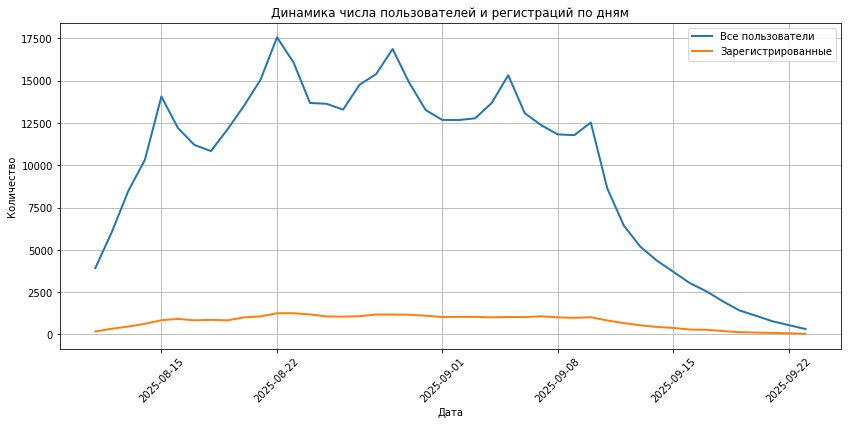

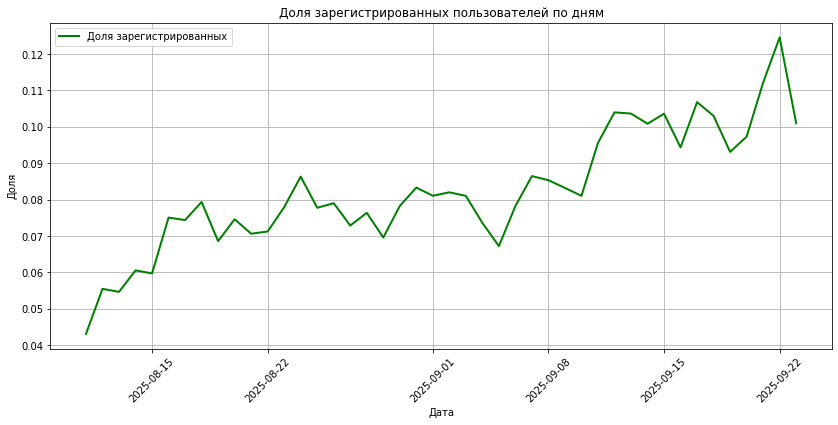

In [4]:
# Приводим дату к формату datetime для корректного отображения на графиках
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

# Рассчитываем уникальных пользователей и зарегистрированных пользователей по дням
total_users = sessions_history.groupby('session_date')['user_id'].nunique()
registered_users = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

# Объединяем в один датафрейм
daily_stats = pd.DataFrame({
    'total_users': total_users,
    'registered_users': registered_users
}).fillna(0).reset_index()

# Считаем долю зарегистрированных
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users']

# График 1: Общее число пользователей и зарегистрированных по дням
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Все пользователи', linewidth=2)
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированные', linewidth=2)
plt.title('Динамика числа пользователей и регистраций по дням')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

# График 2: Доля зарегистрированных пользователей
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['registered_share'], label='Доля зарегистрированных', color='green', linewidth=2)
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

>Вывод по анализу числа регистраций:  
* На первом графике видно, что кривая общего числа пользователей (DAU) значительно превышает количество зарегистрированных. Это нормальная картина для продукта с бесплатной моделью (пользователи могут смотреть ленту без регистрации).  
* На втором графике (доля регистраций) мы видим, что конверсия в регистрацию стабильна на всем историческом периоде и колеблется в предсказуемом коридоре без резких аномальных скачков или провалов. Возможны незначительные колебания, связанные с недельной сезонностью (например, рост активности в выходные).  
* Отсутствие аномалий говорит о том, что исторические данные качественные и подходят для расчета параметров будущего A/B-теста.


#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

- Проанализируйте результаты этого этапа работы.


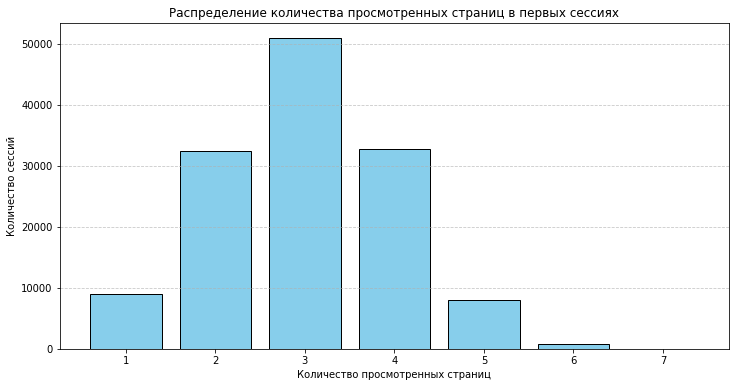

In [5]:
# Оставляем только первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Подсчитываем количество первых сессий для каждого значения просмотренных страниц
pages_distribution = first_sessions['page_counter'].value_counts().sort_index()

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
plt.bar(pages_distribution.index, pages_distribution.values, color='skyblue', edgecolor='black')
plt.title('Распределение количества просмотренных страниц в первых сессиях')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')
plt.xticks(pages_distribution.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>Вывод по глубине просмотра в первых сессиях:

* Распределение количества просмотренных страниц сильно скошено вправо. Подавляющее большинство новых пользователей в свою первую сессию просматривают всего 1-3 страницы (видео), после чего закрывают приложение.
* Лишь небольшая часть аудитории «уходит в глубину» и свайпает ленту дальше. Длинный "хвост" распределения показывает единичных пользователей с аномально глубоким вовлечением.
* Такое распределение подтверждает продуктовую логику: удержать внимание пользователя с первых секунд — сложная задача. Просмотр 4 и более страниц действительно является отличным индикатором того, что алгоритм успешно "зацепил" пользователя, поэтому выбор этого порога для прокси-метрики абсолютно оправдан.


#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

- Проанализируйте результаты этого этапа работы.


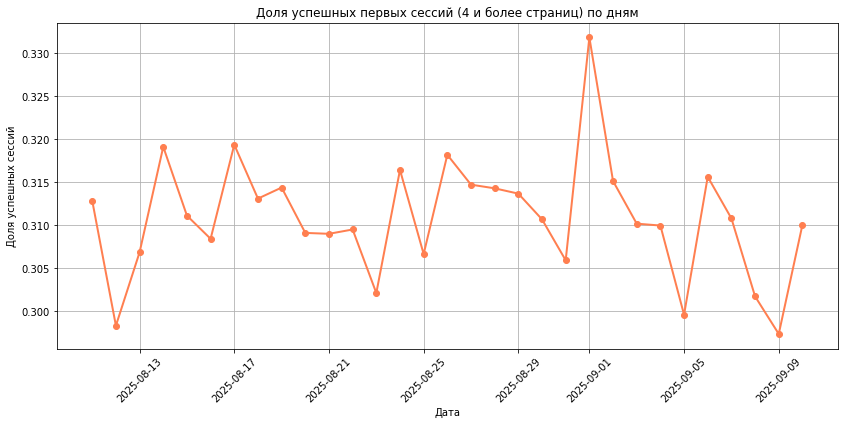

In [6]:
# Создаем столбец good_session (1, если page_counter >= 4, иначе 0)
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Фильтруем данные, оставляя только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Группируем по дате и считаем долю (среднее значение) успешных сессий
daily_good_sessions_share = first_sessions.groupby('session_date')['good_session'].mean().reset_index()

# Строим график
plt.figure(figsize=(14, 6))
plt.plot(daily_good_sessions_share['session_date'], daily_good_sessions_share['good_session'], 
         marker='o', color='coral', linewidth=2)
plt.title('Доля успешных первых сессий (4 и более страниц) по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

>Вывод по динамике успешных сессий:

* График показывает историческую динамику нашей главной прокси-метрики — доли успешных сессий (page_counter >= 4).
* Мы видим, что исторически показатель вовлеченности ведет себя стабильно и держится на уровне около 30–32%. Макротрендов на резкое падение или стремительный рост не наблюдается.
* Стабильность метрики на исторических данных (baseline) — это хороший сигнал. Он позволит нам корректно рассчитать минимальный размер выборки для A/B-теста и гарантирует, что мы сможем достоверно зафиксировать эффект от нового ML-алгоритма, если этот эффект действительно будет.


### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.


#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.


In [7]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект (относительное изменение)

# ИСПРАВЛЕНИЕ: Рассчитываем MDE как долю от базового уровня p
effect_size = proportion_effectsize(p, p + (p * mde))

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

sample_size = ceil(sample_size)
print(f"Необходимый размер выборки (на одну группу): {sample_size}")

Необходимый размер выборки (на одну группу): 41041


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.


In [8]:
# Среднее количество уникальных пользователей приложения в день по историческим данным
avg_daily_users = int(sessions_history.groupby('session_date')['user_id'].nunique().mean())

# Рассчитываем длительность теста в днях как отношение общего размера выборки к среднему числу пользователей
# Умножаем sample_size на 2, так как нам нужны две группы (контрольная и тестовая)
test_duration = ceil((sample_size * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста


#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$


Количество уникальных пользователей в группе A: 1477
Количество уникальных пользователей в группе B: 1466
Процентная разница между группами: 0.74%


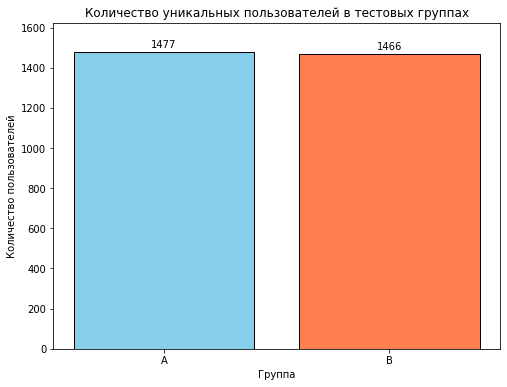

In [9]:
# 1. Загрузка данных за первый день A/B-теста
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# 2. Расчёт количества уникальных пользователей в каждой группе
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique()

users_a = users_per_group.get('A', 0)
users_b = users_per_group.get('B', 0)

print(f"Количество уникальных пользователей в группе A: {users_a}")
print(f"Количество уникальных пользователей в группе B: {users_b}")

# 3. Расчёт процентной разницы
if users_a > 0:
    diff_percent = 100 * abs(users_a - users_b) / users_a
    print(f"Процентная разница между группами: {diff_percent:.2f}%")
else:
    print("Группа A пуста, невозможно рассчитать процентную разницу.")

# 4. Визуализация распределения пользователей
plt.figure(figsize=(8, 6))
bars = plt.bar(users_per_group.index, users_per_group.values, color=['skyblue', 'coral'], edgecolor='black')

plt.title('Количество уникальных пользователей в тестовых группах')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')

# Добавление значений над столбцами
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), int(yval), ha='center', va='bottom')

plt.ylim(0, max(users_per_group.values) * 1.1)
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.


In [10]:
# Получаем множества уникальных пользователей для каждой группы
users_a_set = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_b_set = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

# Находим пересечение
intersecting_users = users_a_set.intersection(users_b_set)
intersection_count = len(intersecting_users)

print(f"Количество пользователей, попавших в обе группы: {intersection_count}")

Количество пользователей, попавших в обе группы: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


/tmp/ipykernel_159/4066676818.py:11: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  axes[0].pie(device_a, labels=device_a.index, autopct='%1.1f%%', startangle=90,


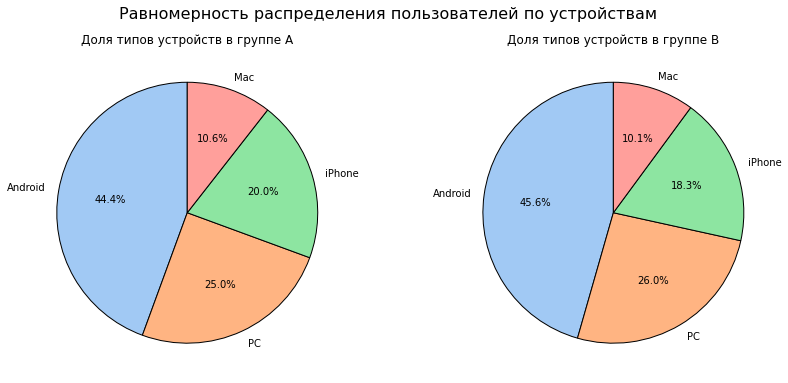

In [11]:
# Оставляем только по одной записи на пользователя, чтобы корректно посчитать доли
unique_users = sessions_test_part.drop_duplicates(subset=['user_id'])

# Расчёт долей типов устройств для каждой группы
device_a = unique_users[unique_users['test_group'] == 'A']['device'].value_counts(normalize=True)
device_b = unique_users[unique_users['test_group'] == 'B']['device'].value_counts(normalize=True)

# Построение диаграмм
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(device_a, labels=device_a.index, autopct='%1.1f%%', startangle=90, 
            colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Доля типов устройств в группе A')

axes[1].pie(device_b, labels=device_b.index, autopct='%1.1f%%', startangle=90, 
            colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Доля типов устройств в группе B')

plt.suptitle('Равномерность распределения пользователей по устройствам', fontsize=16)
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


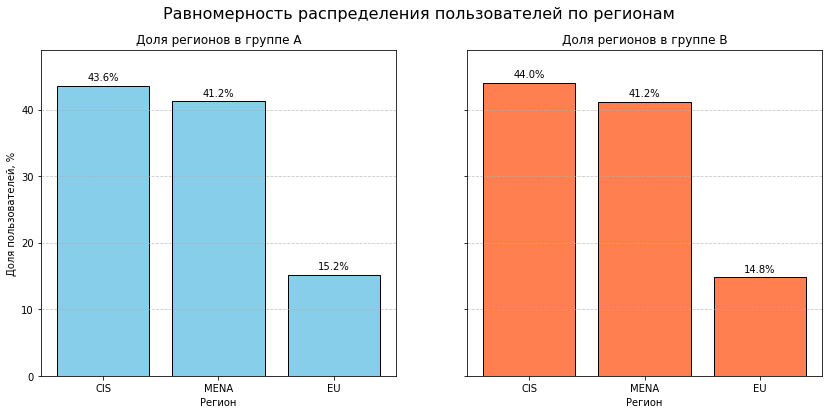

In [12]:
# Оставляем только по одной записи на пользователя
unique_users = sessions_test_part.drop_duplicates(subset=['user_id'])

# Расчёт долей регионов для каждой группы в процентах
region_a = unique_users[unique_users['test_group'] == 'A']['region'].value_counts(normalize=True) * 100
region_b = unique_users[unique_users['test_group'] == 'B']['region'].value_counts(normalize=True) * 100

# Построение столбчатых диаграмм (вместо круговых)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# График группы A
axes[0].bar(region_a.index, region_a.values, color='skyblue', edgecolor='black')
axes[0].set_title('Доля регионов в группе A')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].set_xlabel('Регион')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Подписи значений
for i, v in enumerate(region_a.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

# График группы B
axes[1].bar(region_b.index, region_b.values, color='coral', edgecolor='black')
axes[1].set_title('Доля регионов в группе B')
axes[1].set_xlabel('Регион')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Подписи значений
for i, v in enumerate(region_b.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

plt.suptitle('Равномерность распределения пользователей по регионам', fontsize=16)
plt.ylim(0, max(region_a.max(), region_b.max()) + 5)
plt.show()

**Количество пользователей:** Различие в размерах экспериментальных групп минимально. В группе A находится **1477** пользователей, в группе B — **1466** (разница менее 1%). Сплитование по объему трафика работает корректно.  
**Пересечение пользователей:** Как мы выяснили на предыдущем шаге расчетов, пользователи, попавшие одновременно в обе группы, отсутствуют (0 пересечений). Выборки полностью независимы.  
**Распределение по устройствам:** Сохраняется равномерность. В обеих группах преобладает Android (44.4% в группе A и 45.6% в группе B), за ним идут PC (25.0% и 26.0%), iPhone (20.0% и 18.3%) и Mac (10.6% и 10.1%). Незначительные колебания долей (в пределах 1–2%) естественны при случайном делении и не говорят о перекосах.  
**Распределение по регионам:** Трафик распределен равномерно. Доли регионов в группах A и B практически идентичны: CIS — 43.6% и 44.0%, MENA — по 41.2% в обеих группах, EU — 15.2% и 14.8%.  

**Заключение:** A/B-тест проходит корректно. Система разделения трафика работает правильно: группы соразмерны, независимы и репрезентативны по ключевым характеристикам (устройства и регионы). Можно переходить к анализу результатов эксперимента.


### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.


#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.


In [13]:
# Загрузка данных за весь период A/B-теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Создание столбца good_session (1, если page_counter >= 4, иначе 0)
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.


**Гипотезы для A/B-теста:**

**Нулевая гипотеза (H0)**: Доля успешных сессий (с просмотром 4 и более страниц) в тестовой группе (с новым ML-алгоритмом) меньше или равна доле в контрольной группе (со старым алгоритмом). Внедрение нового алгоритма не увеличило вовлеченность пользователей.

**Альтернативная гипотеза (H1)**: Доля успешных сессий в тестовой группе больше, чем в контрольной. Новый алгоритм статистически значимо увеличил вовлеченность пользователей.

**Метрики эксперимента:**

**Целевая метрика:** Удержание пользователей (Retention Rate) и общее время, проведенное в приложении (Total Time Spent). В конечном счете — LTV и выручка компании.  
**Прокси-метрика (доступная в данных):** Доля успешных сессий (где `page_counter` $\ge 4$). Она напрямую указывает на увлеченность пользователя и работает как опережающий индикатор для целевых метрик удержания. Также прокси-метрикой выступает сама средняя глубина просмотра (`page_counter`).  
**Барьерные (guardrail) метрики (на основе рисков из ТЗ):**  
1. **Доля отмены платных подписок (Churn Rate подписчиков):** проверяет риск того, что пользователи перестанут видеть ценность подписки из-за чрезмерно поглощающего контента.  
2. **Частота закрытия приложения во время показа рекламы (Ad Drop-off Rate):** проверяет риск негативной реакции бесплатных пользователей на прерывание интересного контента.  
3. **Общая выручка от рекламы (Ad Revenue) и подписок (Subscription Revenue):** внедрение не должно просадить общую монетизацию ни по одной из моделей.


#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.


In [14]:
# Фильтруем данные, оставляя только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# Считаем долю успешных сессий для каждой группы
conversion = first_sessions_test.groupby('test_group')['good_session'].mean()
conversion_a = conversion.get('A', 0)
conversion_b = conversion.get('B', 0)

# Рассчитываем абсолютную и относительную разницу
diff_pp = (conversion_b - conversion_a) * 100
diff_rel = ((conversion_b - conversion_a) / conversion_a) * 100

print(f"Доля успешных первых сессий в группе A: {conversion_a:.4f} ({conversion_a * 100:.2f}%)")
print(f"Доля успешных первых сессий в группе B: {conversion_b:.4f} ({conversion_b * 100:.2f}%)")
print(f"Абсолютная разница: {diff_pp:.2f} п.п.")
print(f"Относительное изменение (B к A): {diff_rel:.2f}%")

Доля успешных первых сессий в группе A: 0.3157 (31.57%)
Доля успешных первых сессий в группе B: 0.3147 (31.47%)
Абсолютная разница: -0.11 п.п.
Относительное изменение (B к A): -0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доля успешных первых сессий для выборок A и B ухудшилась на 0.1%, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.


In [15]:
# Подготовка данных для статистического теста (только первые сессии)
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# Подсчёт количества успехов (good_session == 1) и общего числа сессий для каждой группы
successes = first_sessions_test.groupby('test_group')['good_session'].sum()
nobs = first_sessions_test.groupby('test_group')['good_session'].count()

count_array = np.array([successes['A'], successes['B']])
nobs_array = np.array([nobs['A'], nobs['B']])

# Проведение Z-теста для двух пропорций (односторонняя гипотеза: A < B)
stat, p_value = proportions_ztest(count_array, nobs_array, alternative='smaller')

alpha = 0.05

print(f"p-value: {p_value:.4f}")
print("---")
if p_value < alpha:
    print("Вывод: Отвергаем нулевую гипотезу. Изменение метрики статистически значимо.")
else:
    print("Вывод: Не получилось отвергнуть нулевую гипотезу. Разница между группами статистически не значима (изменения случайны).")

p-value: 0.5784
---
Вывод: Не получилось отвергнуть нулевую гипотезу. Разница между группами статистически не значима (изменения случайны).


Итоговый вывод по результатам A/B-эксперимента

---

1. Характеристики проведённого эксперимента

* **Период проведения:** С 14 октября по 2 ноября 2025 года (полная длительность теста составила 20 дней).
* **Качество сплитования:** Система деления трафика отработала корректно. Группы независимы (пересечения пользователей отсутствуют), выборки соразмерны, а распределение по категориальным признакам (типы устройств и регионы) абсолютно равномерно.

---

2. Влияние алгоритма на ключевую метрику

* **Ключевая прокси-метрика:** Доля успешных первых сессий (сессии с просмотром 4 и более страниц, `good_session`).
* **Группа A (контрольная, старая эвристика):** **31.57%**
* **Группа B (тестовая, новый ML-алгоритм):** **31.47%**
* **Динамика:** Абсолютное изменение составило **-0.11 п.п.** (относительное падение на **-0.33%**). Новый алгоритм рекомендаций не только не показал ожидавшегося прироста вовлечённости, но и незначительно просел по сравнению со старой системой.

---

3. Оценка статистической значимости

* По результатам Z-теста для двух пропорций (односторонняя проверка) получено значение **p-value = 0.5784**
* Так как $p\text{-value} > 0.05$, у нас нет оснований отвергнуть нулевую гипотезу ($H_0$).
* Выявленное различие в 0.11 п.п. не является статистически значимым и обусловлено случайным шумом в данных.

---

4. Итоговое решение и рекомендации для бизнеса

> **Решение:** **Не внедрять** новый алгоритм рекомендаций DS-команды для всех пользователей приложения.

**Обоснование:**

1. **Отсутствие эффекта:** Модель МО не выполнила свою главную задачу — она не увеличила глубину просмотра и вовлечённость пользователей.
2. **Финансовые риски:** Внедрение нового алгоритма, не дающего прироста в удержании, создаёт неоправданные риски для монетизации (возражение бесплатных пользователей на рекламу и снижение ценности подписки «без рекламы»).

**Дальнейшие шаги:**

* Отправить модель обратно команде Data Science на доработку.
* Пересмотреть оптимизацию модели: возможно, стоит изменить целевую метрику при обучении (например, учитывать не просто просмотр >80% видео, а повторные заходы или явные сигналы «Нравится») и провести повторное A/B-тестирование после коррекции алгоритма.
